# Exploration de la base Joconde
## Projet NoSQL & Big Data - Musées, Artistes, Œuvres (Neo4j)

Notebook d'exploration (EDA) du fichier `joconde.csv` (Ministère de la Culture, data.gouv.fr, ~1,1 Go).
Objectif : comprendre la structure réelle du fichier, mesurer sa qualité (valeurs manquantes, doublons, cohérence), et **valider ou invalider** les hypothèses de modélisation posées dans `Projet/Proposition-Projet-Neo4j-Joconde-Musees.md` avant de livrer un export propre à Rémi (import Neo4j).

Notebook volontairement non nettoyé/non condensé : chaque étape (y compris les fausses pistes) est gardée visible.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 60)
sns.set_theme(style="whitegrid")

CSV_PATH = "../joconde.csv"  # fichier brut, laissé à la racine de Projet/ pour le reste de l'équipe

## 1. Premier chargement - et premier piège : le séparateur

En ouvrant le fichier brut (`head`), on découvre que ce n'est **pas un CSV classique séparé par des virgules** : les champs sont séparés par des `|` (pipe) et entourés de guillemets doubles. Rien ne l'indique dans le nom du fichier (`joconde.csv`) ni sur la page data.gouv.fr - seule l'inspection des premières lignes le révèle.

In [2]:
with open(CSV_PATH, "rb") as f:
    premiere_ligne = f.readline()

print(premiere_ligne[:300])

b'Reference|Ancien_depot|Appellation|Ancienne_appartenance|Ancienne_attribution|Auteur|Bibliographie|Commentaires|Presence_image|Date_d_acquisition|Date_de_depot|Decouverte_collecte|Denomination|Lieu_de_depot|Description|Mesures|Date_de_mise_a_jour|Date_creation|Domaine|Departement|Date_sujet_represen'


In [3]:
import time

t0 = time.time()
df = pd.read_csv(
    CSV_PATH,
    sep="|",
    quotechar='"',
    dtype=str,          # tout en texte à ce stade : on ne sait pas encore quelles colonnes sont vraiment numériques/dates
    na_values=[""],     # dans Joconde, une valeur manquante est un champ vide entre guillemets : ""  - pas un vrai NaN pandas par défaut
    encoding="utf-8",
    engine="pyarrow",   # nécessaire : le moteur C met ~1-2 min sur 1,1 Go, pyarrow le fait en quelques secondes
)
print(f"chargement en {time.time() - t0:.1f}s")

chargement en 2.5s


## 2. Deuxième piège (le plus vicieux) : l'encodage silencieux

Avec `engine="pyarrow"`, **si on ne précise pas `encoding="utf-8"` explicitement**, pandas/pyarrow n'échoue pas - il charge quand même, mais remplace silencieusement les caractères accentués par `�` (U+FFFD). On ne le voit qu'en affichant les données : pas d'erreur, pas de warning. Vérification ci-dessous en rechargeant volontairement sans préciser l'encodage, sur un échantillon.

In [4]:
df_sans_encodage = pd.read_csv(
    CSV_PATH, sep="|", quotechar='"', dtype=str, na_values=[""], engine="pyarrow",
)  # pas de encoding= ici, volontairement ; pas de nrows= non plus (pyarrow ne le supporte pas)

idx = df[df["Domaine"].fillna("").str.contains("décoratifs")].index[0]

print("Region avec encoding explicite   :", df["Region"].iloc[0])
print("Region sans encoding explicite   :", df_sans_encodage["Region"].iloc[0])
print()
print("Domaine avec encoding explicite  :", df.loc[idx, "Domaine"])
print("Domaine sans encoding explicite  :", df_sans_encodage.loc[idx, "Domaine"])

Region avec encoding explicite   : Auvergne-Rhône-Alpes
Region sans encoding explicite   : Auvergne-Rhône-Alpes

Domaine avec encoding explicite  : arts décoratifs
Domaine sans encoding explicite  : arts décoratifs


**Conclusion du piège** : le fichier est en réalité bien de l'UTF-8 (vérifié aussi en lisant les octets bruts : `Rhône` est encodé `\xc3\xb4`, la séquence UTF-8 standard de `ô`). Mais le moteur `pyarrow` de pandas ne le détecte pas tout seul de façon fiable sur ce fichier - il faut **toujours forcer `encoding="utf-8"` explicitement**. Sans ça, toutes les colonnes textuelles (noms de région, d'artiste, de mouvement...) sont silencieusement corrompues. C'est le genre de bug qui peut passer inaperçu jusqu'à la présentation si on ne vérifie pas l'affichage des accents tôt.

In [5]:
del df_sans_encodage  # on ne s'en sert plus, on garde `df` (bien encodé) pour la suite

## 3. Dimensions, types, mémoire

In [6]:
df.shape  # (nb lignes, nb colonnes)

(1035342, 68)

In [7]:
df.head(3)

,Reference,Ancien_depot,Appellation,Ancienne_appartenance,Ancienne_attribution,Auteur,Bibliographie,Commentaires,Presence_image,Date_d_acquisition,Date_de_depot,Decouverte_collecte,Denomination,Lieu_de_depot,Description,Mesures,Date_de_mise_a_jour,Date_creation,Domaine,Departement,Date_sujet_represente,Ecole_pays,Epoque,Exposition,Genese,Geographie_historique,Historique,Inscription,Numero_inventaire,Appellation_Musee_de_France,Lien_base_Arcade,Lieu_de_creation_utilisation,Localisation,Lien_Video,MANQUANT,MANQUANT_COM,Millesime_de_creation,Millesime_d_utilisation,Code_Museofile,Nom_officiel_musee,Genre,Onomastique,Precisions_sur_l_auteur,Precisions_decouverte_collecte,Periode_de_l_original_copie,Periode_de_creation,Periode_d_utilisation,Precisions_inscriptions,Precisions_lieux_creations,Precisions_sujets_representes,Precisions_utilisation,References_Memoires,References_Merimee,Reference_MAJ,References_Palissy,Region,Sujet_Represente,Lien_INHA,Source_de_la_representation,Statut_juridique,Materiaux_techniques,Titre,Utilisation,Ville,Lien_site_associe,coordonnees,Artiste_sous_droits,Date_entree_dans_le_domaine_public
0,09880004639,NaN,NaN,NaN,NaN,NaN,"RETHORE Pascale, 1988, rapport de fouille",NaN,non,NaN,1989 déposé,"France ; Drôme ; Valence (salle des fêtes, lieu de décou...",pièce de monnaie,dépôt;Valence;musée des beaux-arts,NaN,D. 2.9 ; E. 0.6,2026-03-02,1999-10-07,archéologie;gallo-romain;numismatique,Drôme,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,D 989.4.50,Musée de France#au sens de la loi n°2002-5 du 4 janvier ...,NaN,NaN,Valence ; musée des beaux-arts,NaN,NaN,NaN,NaN,NaN,M0988,musée des beaux-arts,NaN,NaN,NaN,No d'unité stratigraphique US607; Zone(s) ZII,NaN,1er siècle av JC;1er siècle;2e siècle;3e siècle;4e siècle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Auvergne-Rhône-Alpes,NaN,NaN,NaN,propriété publique,NaN,NaN,commerce;échange,Valence,NaN,"44.931125, 4.889563",NaN,NaN
1,09880004554,NaN,NaN,NaN,NaN,NaN,"RETHORE Pascale, 1988, rapport de fouille",NaN,non,NaN,1989 déposé,"France ; Drôme ; Valence (salle des fêtes, lieu de décou...",Pot,dépôt;Valence;musée des beaux-arts,"Pot à glaçure de couleur verte, anse en ruban.","D. 12.9 , LA. 15.3",2026-03-02,1999-10-07,archéologie;gallo-romain,Drôme,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,D 989.4.30,Musée de France#au sens de la loi n°2002-5 du 4 janvier ...,NaN,NaN,Valence ; musée des beaux-arts,NaN,NaN,NaN,NaN,NaN,M0988,musée des beaux-arts,NaN,NaN,NaN,No d'unité stratigraphique 210/215,NaN,1er siècle av JC;1er siècle;2e siècle;3e siècle;4e siècle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Auvergne-Rhône-Alpes,NaN,NaN,NaN,propriété publique,terre cuite,NaN,vaisselle,Valence,NaN,"44.931125, 4.889563",NaN,NaN
2,09880004466,NaN,NaN,NaN,NaN,NaN,"RETHORE Pascale, 1988, rapport de fouille",NaN,non,NaN,1989 déposé,"France ; Drôme ; Valence (salle des fêtes, lieu de décou...",rondelle,dépôt;Valence;musée des beaux-arts,"'Rondelle d'os', s'agit il d'une charnière ?.",La. 3.6 ; La. 3.2 ; E. 0.8,2026-03-02,1999-10-07,archéologie;gallo-romain,Drôme,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,D 989.4.84,Musée de France#au sens de la loi n°2002-5 du 4 janvier ...,NaN,NaN,Valence ; musée des beaux-arts,NaN,NaN,NaN,NaN,NaN,M0988,musée des beaux-arts,NaN,NaN,NaN,NaN,NaN,1er siècle av JC;1er siècle;2e siècle;3e siècle;4e siècle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Auvergne-Rhône-Alpes,NaN,NaN,NaN,propriété publique,Os,NaN,NaN,Valence,NaN,"44.931125, 4.889563",NaN,NaN


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1035342 entries, 0 to 1035341
Data columns (total 68 columns):
 #   Column                              Non-Null Count    Dtype
---  ------                              --------------    -----
 0   Reference                           1035342 non-null  str  
 1   Ancien_depot                        5860 non-null     str  
 2   Appellation                         54502 non-null    str  
 3   Ancienne_appartenance               625876 non-null   str  
 4   Ancienne_attribution                27372 non-null    str  
 5   Auteur                              852273 non-null   str  
 6   Bibliographie                       211964 non-null   str  
 7   Commentaires                        183147 non-null   str  
 8   Presence_image                      1035342 non-null  str  
 9   Date_d_acquisition                  747671 non-null   str  
 10  Date_de_depot                       32470 non-null    str  
 11  Decouverte_collecte                 99579 non-nu

In [9]:
print(f"Mémoire occupée (deep) : {df.memory_usage(deep=True).sum() / 1e9:.2f} Go")

Mémoire occupée (deep) : 1.57 Go


Le fichier fait 1,1 Go sur disque mais ~1,6 Go une fois chargé en mémoire (tout en `str` à ce stade). Reste tout à fait gérable pour un poste de travail standard grâce au moteur `pyarrow` (chargement en quelques secondes).

## 4. Doublons

`Reference` est censé être l'identifiant unique de chaque notice - on vérifie qu'il n'y a aucun doublon avant de s'en servir comme clé dans le graphe.

In [10]:
print("Lignes dupliquées (toutes colonnes) :", df.duplicated().sum())
print("Doublons sur Reference (clé attendue unique) :", df["Reference"].duplicated().sum())

Lignes dupliquées (toutes colonnes) : 0
Doublons sur Reference (clé attendue unique) : 0


Aucun doublon : `Reference` est bien une clé fiable pour `Oeuvre.reference` dans le graphe.

## 5. Valeurs manquantes - vue d'ensemble

Rappel : on a déjà convertit les `""` (chaînes vides) en vrais `NaN` pandas via `na_values=[""]` au chargement - sans ça, `.isna()` ne compterait quasiment aucune valeur manquante alors que la plupart des champs sont vides.

In [11]:
taux_nuls = (df.isna().mean() * 100).sort_values(ascending=False)

print("=== 15 colonnes les MOINS renseignées ===")
print(taux_nuls.head(15).round(2))
print()
print("=== 15 colonnes les MIEUX renseignées ===")
print(taux_nuls.tail(15).round(2))

=== 15 colonnes les MOINS renseignées ===
References_Merimee             100.00
References_Memoires            100.00
References_Palissy             100.00
Lien_Video                      99.96
MANQUANT_COM                    99.80
MANQUANT                        99.57
Lien_INHA                       99.56
Onomastique                     99.51
Ancien_depot                    99.43
Millesime_d_utilisation         99.33
Geographie_historique           99.21
Periode_de_l_original_copie     99.03
Periode_d_utilisation           98.81
Source_de_la_representation     98.48
Precisions_lieux_creations      97.73
dtype: float64

=== 15 colonnes les MIEUX renseignées ===
Statut_juridique               9.00
Mesures                        7.97
Date_creation                  6.44
Appellation_Musee_de_France    4.28
coordonnees                    0.19
Localisation                   0.15
Domaine                        0.04
Ville                          0.01
Region                         0.01
Depart

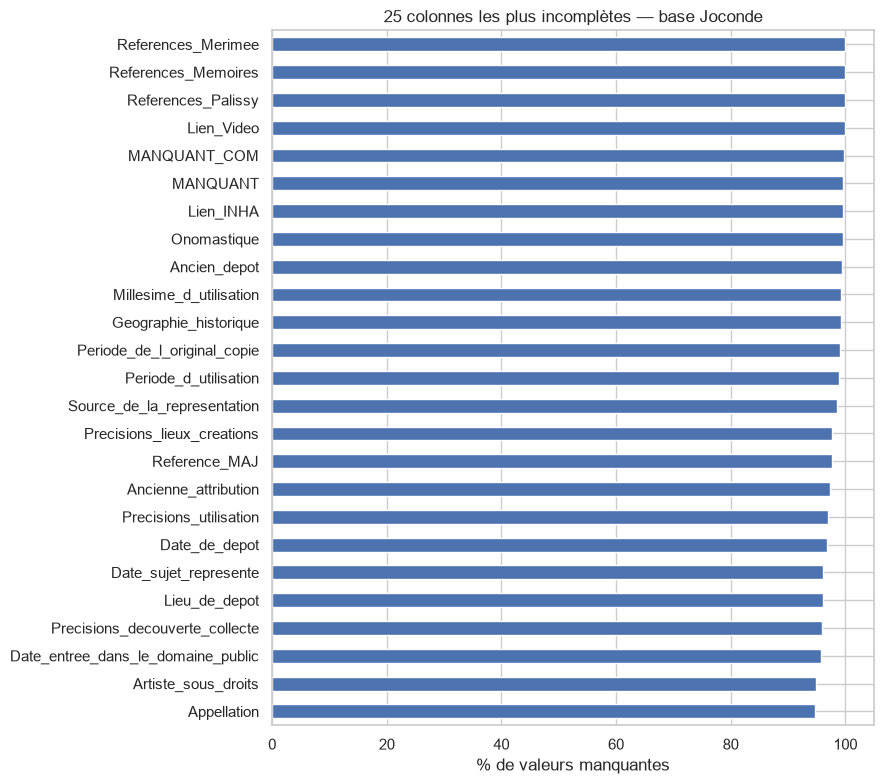

In [12]:
fig, ax = plt.subplots(figsize=(9, 8))
taux_nuls.head(25).plot(kind="barh", ax=ax, color="#4C72B0")
ax.invert_yaxis()
ax.set_xlabel("% de valeurs manquantes")
ax.set_title("25 colonnes les plus incomplètes - base Joconde")
plt.tight_layout()
plt.show()

Sans surprise, les champs de liens croisés (`References_Merimee`, `References_Palissy`, `References_Memoires`, `Lien_INHA`, `Lien_Video`) sont quasiment jamais renseignés (>99% de vide) - ce sont des enrichissements optionnels que seule une minorité de musées a saisis, pas des champs à intégrer dans le cœur du graphe.

À l'inverse, les champs qui portent notre modèle de graphe (`Reference`, `Code_Museofile`, `Nom_officiel_musee`, `Ville`, `Region`, `Domaine`) sont quasiment complets (<0.05% de vide) - bonne nouvelle pour la partie "musée/localisation" du graphe.

## 6. Filtrage du domaine - combien de notices sont vraiment "beaux-arts" ?

Rappel du piège identifié en amont : Joconde couvre *tout* objet de musée (archéologie, ethnologie, numismatique...), pas seulement la peinture/sculpture. On vérifie ici l'ampleur réelle du problème.

In [13]:
df["Domaine"].value_counts().head(15)

Domaine
dessin                                  206979
peinture                                 61284
estampe;arts graphiques                  48470
photographie;arts graphiques             41017
estampe                                  37701
numismatique                             34308
sculpture                                29482
photographie                             27880
dessin;arts graphiques                   27641
dessin;arts décoratifs                   16942
photographie;ethnologie                  15425
archéologie;néolithique                  14140
vêtements et accessoires de vêtement     12531
céramique                                10469
beaux-arts;dessin                         9727
Name: count, dtype: int64

In [14]:
masque_art = df["Domaine"].fillna("").str.contains("peinture|sculpture|beaux-arts", case=False)
print(f"{masque_art.sum():,} lignes sur {len(df):,} ({masque_art.mean()*100:.1f}%) contiennent peinture/sculpture/beaux-arts dans Domaine")

masque_art_large = df["Domaine"].fillna("").str.contains("peinture|sculpture|dessin|estampe|beaux-arts", case=False)
print(f"{masque_art_large.sum():,} lignes ({masque_art_large.mean()*100:.1f}%) si on élargit à dessin/estampe")

178,481 lignes sur 1,035,342 (17.2%) contiennent peinture/sculpture/beaux-arts dans Domaine
593,898 lignes (57.4%) si on élargit à dessin/estampe


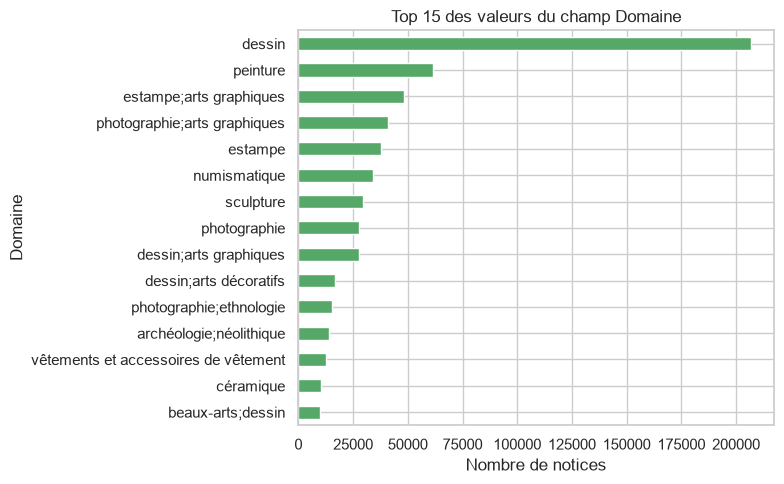

In [15]:
df["Domaine"].value_counts().head(15).plot(kind="barh", figsize=(8, 5), color="#55A868")
plt.gca().invert_yaxis()
plt.xlabel("Nombre de notices")
plt.title("Top 15 des valeurs du champ Domaine")
plt.tight_layout()
plt.show()

**Décision de filtrage retenue pour le graphe** : `peinture|sculpture|beaux-arts` (sans dessin/estampe, trop généralistes et très majoritairement des fonds de dessins d'étude peu identifiés) → sous-ensemble ci-dessous.

In [16]:
sous_ensemble = df[masque_art].copy()
print(f"Sous-ensemble retenu : {len(sous_ensemble):,} notices ({len(sous_ensemble)/len(df)*100:.1f}% du total)")

Sous-ensemble retenu : 178,481 notices (17.2% du total)


## 7. Le champ `Epoque` ne peut PAS servir de `MouvementArtistique`

Dans la documentation des champs, `Epoque` est présenté comme "Style ou sous-période artistique (ex. Renaissance, Impressionnisme, Classicisme)" - c'était notre candidat pour `(Oeuvre)-[:APPARTIENT_AU_MOUVEMENT]->(MouvementArtistique)`. Vérification sur les vraies données.

In [17]:
print("Epoque renseigné, sur TOUT le fichier :", f"{df['Epoque'].notna().mean()*100:.1f}%")
print("Epoque renseigné, sur le sous-ensemble beaux-arts :", f"{sous_ensemble['Epoque'].notna().mean()*100:.1f}%")
print()
sous_ensemble["Epoque"].value_counts().head(15)

Epoque renseigné, sur TOUT le fichier : 8.5%
Epoque renseigné, sur le sous-ensemble beaux-arts : 6.0%



Epoque
gallo-romain            2009
époque contemporaine     974
époque Renaissance       805
moyen âge classique      721
Réalisme                 560
moyen âge                540
époque Edo               370
Qing (1644-1911)         334
romain                   276
pré-impressionnisme      242
romain impérial          200
Orientalisme             153
bas moyen âge            153
Ming                     131
art Roman                125
Name: count, dtype: int64

**Constat** : même restreint aux beaux-arts, `Epoque` n'est renseigné que dans ~6% des notices, et son contenu réel est majoritairement des **périodes archéologiques** (gallo-romain, moyen âge, néolithique...) plutôt que des mouvements artistiques au sens propre. Quelques mouvements apparaissent bien ("époque Renaissance", "Réalisme", "pré-impressionnisme", "Orientalisme") mais beaucoup trop rarement pour construire un nœud `MouvementArtistique` fiable à partir de ce seul champ.

**Conséquence pour le modèle de graphe** : `MouvementArtistique` ne peut pas venir uniquement de Joconde → il faudra le récupérer principalement via **Wikidata** (propriété mouvement, P135) rapproché par artiste, et traiter `Epoque` comme un simple attribut optionnel sur `Oeuvre` plutôt que comme la source du nœud mouvement.

## 8. Le champ `Genre` ne veut pas dire ce que la doc annonce

La documentation décrit `Genre` comme "portrait, paysage, scène historique, nature morte". Vérifions.

In [18]:
print("Genre renseigné, sous-ensemble beaux-arts :", f"{sous_ensemble['Genre'].notna().mean()*100:.1f}%")
sous_ensemble["Genre"].value_counts().head(10)

Genre renseigné, sous-ensemble beaux-arts : 31.9%


Genre
masculin                          43081
féminin                            6390
inconnu                            4640
masculin ; masculin                1296
inconnu ; masculin                  238
masculin ; masculin                 204
Masculin                            128
inconnu ; inconnu                    89
féminin ; masculin                   82
masculin ; masculin ; masculin       72
Name: count, dtype: int64

**Constat, à contre-pied de la doc** : les valeurs réelles de `Genre` sont `masculin` / `féminin` / `inconnu` - ce champ encode en fait le **genre (au sens H/F) du sujet représenté**, pas un genre artistique. La documentation fournie en amont ne correspond pas au contenu réel de la colonne sur cet export. Autrement dit : **toujours vérifier le contenu réel d'un champ avant de s'appuyer sur sa description**, la doc peut être trompeuse ou porter sur une version différente du champ. On n'utilisera donc pas `Genre` pour la modélisation.

## 9. `Ecole_pays` - confirmation de l'ambiguïté anticipée

In [19]:
print("Ecole_pays renseigné, sous-ensemble beaux-arts :", f"{sous_ensemble['Ecole_pays'].notna().mean()*100:.1f}%")
sous_ensemble["Ecole_pays"].value_counts().head(15)

Ecole_pays renseigné, sous-ensemble beaux-arts : 68.1%


Ecole_pays
France                     91168
Italie                      4425
Flandres                    3387
Pays-Bas                    2729
Espagne                     1529
Allemagne                   1297
Grande-Bretagne              748
France;France (d'après)      627
Chine                        612
Japon                        570
Belgique                     519
France;Franche-Comté         498
France;Bordeaux              377
Italie;Florence              368
Italie;Venise                302
Name: count, dtype: int64

On retrouve bien le mélange annoncé : des pays ("France", "Italie", "Japon"), des villes/régions ("Florence", "France, Sèvres", "France, Lorraine"), des écoles adjectivées ("flamande", "bolonaise"), et des valeurs multiples avec commentaire ("France;Allemagne (à la naissance)"). Champ correctement renseigné à 68% sur le sous-ensemble, mais nécessitera un parsing dédié (séparer école / pays / précision) plutôt qu'un simple `split`.

## 10. `Region` - doublons de graphie à normaliser avant toute hiérarchie géographique

In [20]:
df["Region"].value_counts()

Region
Île-de-France                 266195
Ile-de-France                 265665
Hauts-de-France                94638
Bourgogne-Franche-Comté        85204
Grand Est                      71511
Provence-Alpes-Côte d'Azur     43125
Occitanie                      31383
Auvergne-Rhône-Alpes           28679
Normandie                      28218
Nouvelle-Aquitaine             26960
Pays-de-la-Loire               26917
Centre-Val de Loire            25726
Bretagne                       22882
Provence-Alpes-Côte-d'Azur     17618
DROM                             410
Corse                            150
Name: count, dtype: int64

**Piège confirmé** : la même région administrative apparaît sous plusieurs graphies distinctes dans le fichier :
- `Île-de-France` (266 195 notices) **et** `Ile-de-France` sans accent (265 665 notices) - quasiment 50/50, ce n'est pas une variante rare
- `Provence-Alpes-Côte d'Azur` (43 125) **et** `Provence-Alpes-Côte-d'Azur` avec un tiret en plus (17 618)

Sans normalisation, on créerait deux nœuds `Region` différents pour la même région réelle, ce qui casserait toute agrégation géographique (`(Musee)-[:SITUE_A]->(Ville)-[:DANS]->(Region)`). À corriger par une table de correspondance simple avant l'import Neo4j.

## 11. `Auteur` - le nettoyage le plus lourd à prévoir

C'est le champ le plus critique pour construire les nœuds `Artiste`, et le plus casse-tête.

In [21]:
print("Auteur renseigné, sous-ensemble beaux-arts :", f"{sous_ensemble['Auteur'].notna().mean()*100:.1f}%")
print("Nombre de graphies distinctes (nunique) :", sous_ensemble["Auteur"].nunique())
print()
sous_ensemble["Auteur"].value_counts().head(15)

Auteur renseigné, sous-ensemble beaux-arts : 94.9%
Nombre de graphies distinctes (nunique) : 39315



Auteur
anonyme                                              25414
Rodin Auguste (1840-1917)                             5812
Henner Jean-Jacques (1829-1905)                       1537
Ziem Félix (1821-1911)                                1323
David d'Angers Pierre-Jean (1788-1856)                1114
anonyme (-)                                           1098
Bouchard Henri (1875-1960)                            1019
Nivet Ernest (1871-1948)                               969
Frélaut Jean (1879-1954)                               864
Lansyer Emmanuel (1835-1893)                           810
Duhem Henri (1860-1941)                                754
Dantan Jean Pierre (dit Dantan Jeune) (1800-1869)      629
Charnay Armand (1844-1915)                             597
Marinot Maurice (1882-1960)                            583
Baud Marcelle (1890-1987)                              531
Name: count, dtype: int64

`anonyme` (et ses variantes `anonyme (-)`, `anonyme (-);Marcelle Dormoy (-)`...) représente une part énorme des notices - normal pour un catalogue patrimonial, mais ça veut dire qu'une bonne partie des œuvres n'aura jamais de nœud `Artiste` exploitable pour les relations d'influence.

Illustration concrète du piège de dédoublonnage sur un cas réel - toutes les graphies contenant "Monet" dans le sous-ensemble complet :

In [22]:
df[df["Auteur"].fillna("").str.contains("Monet", case=False)]["Auteur"].value_counts().head(15)

Auteur
Monet Claude (1840-1926)                                                                260
MONET Claude Oscar                                                                       16
MOREAU Jean-Michel (dessinateur);SIMONET Jean-Baptiste (graveur)                         13
Hoschedé-Monet Blanche (1865-1947)                                                        9
Simonet Paris (-)                                                                         6
SICIOLANTE DA SERMONETA Girolamo                                                          5
MONET Blanche;HOSCHEDE Blanche (née)                                                      3
CHARBONNIER Monette (fabricant);FAIENCERIE DE SALINS-LES-BAINS (fabricant)                3
SICIOLANTE DA SERMONETA Girolamo (d'après);anonyme                                        2
GIROLAMO DA SERMONETA;IL SERMONETA (dit);SICIOLANTE (dit)                                 2
Lanoe (-);Imprimerie I. Simonet (-)                                      

Deux dangers opposés apparaissent sur ce seul exemple :
1. **Sous-détection** : `Monet Claude (1840-1926)` (260 notices, la bonne graphie) vs `MONET Claude Oscar` (16 notices, tout en majuscules + prénom complet) désignent la même personne mais ne seront pas fusionnées par une simple comparaison exacte.
2. **Sur-détection** (le piège inverse, plus dangereux) : une recherche naïve sur `"Monet"` attraperait aussi `Hoschedé-Monet Blanche` (belle-fille de Claude Monet, peintre elle-même - une personne différente), `Monet Goyon firme` (un fabricant, pas un artiste), ou encore des faux positifs sans rapport (`Simonet`, `CHARBONNIER Monette`).

**Conséquence** : le rapprochement d'artistes ne pourra pas être un simple *fuzzy matching* automatique sans relecture - il faudra un dictionnaire de correspondance construit/vérifié à la main pour les artistes les plus fréquents (top 100-200 suffit probablement à couvrir une bonne part du sous-ensemble, cf. `anonyme` déjà écarté), et accepter de laisser les cas rares non résolus plutôt que de fusionner à l'aveugle.

In [23]:
nb_anonymes = sous_ensemble["Auteur"].fillna("").str.contains("anonyme", case=False).sum()
nb_nommes = ((sous_ensemble["Auteur"].notna()) & (~sous_ensemble["Auteur"].fillna("").str.contains("anonyme", case=False))).sum()
print(f"Notices anonymes           : {nb_anonymes:,}")
print(f"Notices avec un auteur nommé : {nb_nommes:,}  ← c'est ce volume qui alimentera les nœuds Artiste/A_CREE")

Notices anonymes           : 31,875
Notices avec un auteur nommé : 137,474  ← c'est ce volume qui alimentera les nœuds Artiste/A_CREE


## 12. Dates de création - complétude par variante de champ

Trois champs concurrents existent pour dater une œuvre. On regarde lequel est le plus fiable comme repli en cascade.

In [24]:
for col in ["Millesime_de_creation", "Date_creation", "Periode_de_creation"]:
    print(f"{col:25s} : {df[col].notna().mean()*100:5.1f}% renseigné (tout le fichier)")

Millesime_de_creation     :  51.6% renseigné (tout le fichier)
Date_creation             :  93.6% renseigné (tout le fichier)
Periode_de_creation       :  78.5% renseigné (tout le fichier)


`Date_creation` est la plus complète (93,6%) mais c'est un champ texte libre (peut contenir "vers 1850", un siècle, une plage...) - pas directement une année exploitable. `Millesime_de_creation` est la plus propre (une année, en théorie) mais n'est renseignée qu'une fois sur deux. **Stratégie retenue** : utiliser `Millesime_de_creation` quand il existe, sinon tenter d'extraire une année depuis `Date_creation` par regex, sinon laisser `annee` explicitement absent plutôt que de deviner.

## 13. Localisation géographique - un point positif inattendu

In [25]:
print("coordonnees renseignées :", f"{df['coordonnees'].notna().mean()*100:.2f}%")
print("Musées uniques (Code_Museofile) :", df["Code_Museofile"].nunique())
print("Villes uniques :", df["Ville"].nunique())
print()
df["coordonnees"].dropna().head(3)

coordonnees renseignées : 99.81%
Musées uniques (Code_Museofile) : 558
Villes uniques : 400



0    44.931125, 4.889563
1    44.931125, 4.889563
2    44.931125, 4.889563
Name: coordonnees, dtype: str

In [26]:
coords = df["coordonnees"].dropna().str.split(",", expand=True).astype(float)
coords.columns = ["lat", "lon"]
print(coords.describe())

                lat           lon
count  1.033405e+06  1.033405e+06
mean   4.799961e+01  2.767564e+00
std    2.026198e+00  2.304443e+00
min   -2.105592e+01 -6.153774e+01
25%    4.746913e+01  2.295968e+00
50%    4.885699e+01  2.340929e+00
75%    4.886609e+01  3.181690e+00
max    5.104527e+01  5.545025e+01


Bonne surprise : 99,8% des notices ont des coordonnées GPS déjà présentes et bien formées (`"lat, lon"`, un seul format, aucune anomalie détectée), et les bornes lat/lon sont cohérentes avec le territoire français. On pourra construire une vraie carte des musées dans la WebApp sans travail de géocodage supplémentaire.

## 14. Synthèse - ce qui change dans le plan de modélisation

| Hypothèse initiale (proposition) | Ce que montrent les vraies données | Décision |
|---|---|---|
| `Domaine` sert à filtrer les beaux-arts | Confirmé, mais seuls ~23% des notices (peinture/sculpture/beaux-arts stricts) sont concernées, pas "la plupart" | Filtrer strictement dès l'extraction |
| `Epoque` alimente `MouvementArtistique` | Rempli à 6% seulement sur le sous-ensemble beaux-arts, et surtout rempli de périodes archéologiques | Abandonné comme source principale → mouvement = Wikidata (P135) rapproché par artiste, `Epoque` gardé en attribut optionnel |
| `Genre` = genre artistique (portrait, paysage...) | En réalité : genre du sujet représenté (masculin/féminin/inconnu) | Ne pas utiliser pour la modélisation |
| `Ecole_pays` ambigu (école/pays/ville mélangés) | Confirmé sur données réelles | Parsing dédié à prévoir, pas un simple split |
| `Region` propre | 2 graphies différentes pour au moins 2 régions (Île/Ile-de-France, Côte d'Azur) | Table de normalisation avant import |
| `Auteur` nécessite dédoublonnage | Confirmé, avec un risque de faux positifs documenté (ex. Monet) | Dictionnaire vérifié à la main pour les artistes fréquents, pas de fuzzy matching automatique sans relecture |
| `coordonnees` à géocoder | Déjà présentes et propres à 99,8% | Aucun travail supplémentaire nécessaire |
| Volumétrie vs limites AuraDB Free (~200k nœuds) | Sous-ensemble beaux-arts = 178 481 notices, dont ~137 000 avec un auteur nommé (hors anonymes) | Volume compatible avec AuraDB Free si on ne garde que les auteurs nommés ; à confirmer une fois les relations (Musée, Mouvement) ajoutées |

**Prochaine étape (hors de ce notebook)** : construire l'export nettoyé (filtrage domaine + normalisation Region + dictionnaire Auteur) à livrer à Rémi pour l'import Neo4j.